In [28]:
import pystac_client
import odc.stac
import matplotlib.pyplot as plt

In [ ]:
# Link to ccmeo datacube stac-api
stac_root = "https://datacube.services.geo.ca/stac/api"

# Initialize the STAC client
catalog = pystac_client.Client.open(stac_root)

# Define search parameters

collections = ['mrdem-30']

extent = [-63.67731,44.60749, -63.54322,44.69135]

# Build the search query with the filtering parameters
search = catalog.search(
    collections=collections, 
    bbox=extent
    )

In [14]:
item_collection  = search.item_collection()

In [15]:
ds = odc.stac.load(item_collection,
                    chunks={'x': 1000, 'y': 1000},
                    use_overviews=True,
                    resolution=20,
                    bbox=extent
                    )

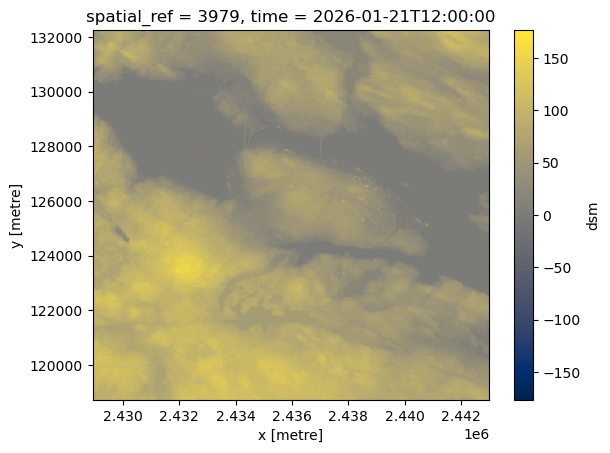

In [27]:
ds.isel(time=0).dsm.plot.imshow(cmap='cividis')